# Notebook 5 — CSP + LDA/SVM: The Traditional BCI Baseline

## Section 0 — What we're building on

### Prior concepts you already have

From the **preprocessing pipeline** notebook, you know:
- **CSP as an API call** — you've used `mne.decoding.CSP` and seen that it returns spatial filters that produce features which separate classes.
- **Epoch-level splitting** before windowing to avoid data leakage.
- **`run_pipeline()`** returns `X_train, X_test, y_train, y_test` already z-scored, with shape `(n_trials, C=22, T=250)`.

From the **EEG exploration** notebook, you know:
- Contralateral ERD: left hand imagery suppresses mu/beta power over **C4** (right motor cortex); right hand suppresses over **C3**.
- Band power differences between classes are the *physical signal* a BCI decoder must exploit.

From the **signal processing** notebook, you know:
- Band power = integral of PSD over a frequency band.
- Variance of a band-passed signal is proportional to its band power (Parseval's theorem).

### What this notebook adds

Three new things, in order:

1. **CSP derivation** — you'll move from *calling* `mne.decoding.CSP` to *understanding* what it optimizes: a generalized eigenvalue problem on class covariance matrices. You'll implement CSP in NumPy from scratch and verify it matches MNE's output.
2. **LDA geometry** — Linear Discriminant Analysis as a closed-form classifier that projects features onto a direction maximizing class separability. You'll see the within-class/between-class scatter formulation.
3. **SVM margin maximization** — why maximizing the margin gives better generalization than LDA when class-conditional Gaussianity is violated.

### Clinical / practical context

CSP + LDA is **the** published benchmark on BCI Competition IV Dataset 2a. The competition winner (Ang et al., 2008, "Filter Bank CSP") used a CSP variant and still beats many deep learning papers on small subject-specific datasets. For a deployed consumer BCI with ~300 calibration trials per user, CSP+LDA is often the right default: it's interpretable (spatial filters can be plotted as topographies), trains in milliseconds, and has no hyperparameters to tune beyond `n_components`.

> **Why X?** If you build a BCI product today, you will almost certainly benchmark against CSP+LDA before claiming a deep learning model is better. Reviewers in the BCI literature expect this comparison. By the end of this notebook, you should be able to reproduce numbers comparable to the Dataset 2a leaderboard.


## Imports and setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix

from mne.decoding import CSP as MNE_CSP

# Import the pipeline function built in Notebook 3
import sys
sys.path.insert(0, '../4.data preprocessing')
from run_pipeline import run_pipeline

DATA_DIR = '../mne_data/bci_iv_2a'  # adjust to your local path

np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 5)

### Compute note

This notebook does **not** train deep models. CSP is a closed-form eigenvalue problem; LDA and SVM on ~288 trials fit in under a second per subject. No GPU is needed. The full 9-subject sweep at the end of this notebook should finish in under a minute on CPU.


## Part 1 — Load one subject and inspect the data

We'll start with subject A01 for development. The full 9-subject sweep comes at the end.

Recall from Notebook 3 that `run_pipeline()` returns:
- `X_train`, `X_test` — shape `(n_trials, 22, 250)`, z-scored, already band-passed 8–30 Hz (mu + beta, the motor imagery bands).
- `y_train`, `y_test` — integer labels in `{0, 1, 2, 3}` for left hand / right hand / feet / tongue.

> **Why 8–30 Hz?** Motor imagery produces ERD in mu (8–13 Hz) and beta (13–30 Hz). Restricting to this band is a strong prior: it throws away delta/theta/gamma content that carries little discriminative signal for motor imagery and would otherwise pollute CSP's covariance estimates.


In [2]:
data = run_pipeline('A01', DATA_DIR)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

print(f"X_train shape: {X_train.shape}  (n_trials, C=22, T=250)")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, classes present: {np.unique(y_train)}")
print(f"Class counts (train): {np.bincount(y_train)}")

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
X_train shape: (690, 22, 250)  (n_trials, C=22, T=250)
X_test  shape: (174, 22, 250)
y_train shape: (690,), classes present: [0 1 2 3]
Class counts (train): [171 174 171 174]


## Part 2 — CSP from scratch

### 2.1 What CSP optimizes (formal definition)

CSP (Common Spatial Patterns) finds spatial filters — linear combinations of the 22 EEG channels — whose **variance differs maximally between two classes**. In motor imagery:
- Left hand imagery → C4-area power drops → variance of a filter that highlights C4 drops.
- Right hand imagery → C3-area power drops → variance of a filter that highlights C3 drops.

CSP formalizes "find the spatial filter that maximally separates class variances."

#### The math

For a band-passed EEG trial $X \in \mathbb{R}^{C \times T}$ (22 channels, 250 timepoints), the **normalized spatial covariance** is:

$$
\Sigma = \frac{X X^\top}{\text{tr}(X X^\top)} \in \mathbb{R}^{C \times C}
$$

- $X X^\top$ is the unnormalized covariance — the $(i, j)$ entry is $\sum_t X_{i,t} X_{j,t}$, the dot product of channel $i$ and channel $j$ over time.
- Dividing by $\text{tr}(X X^\top)$ (sum of channel variances) normalizes out overall signal magnitude, so trials with higher absolute amplitude don't dominate.

Average across trials of class $c$ to get $\bar\Sigma_c$. For binary CSP (say, class 0 vs class 1), define the composite covariance $\Sigma_c = \bar\Sigma_0 + \bar\Sigma_1$.

CSP finds a spatial filter $w \in \mathbb{R}^C$ that maximizes:

$$
J(w) = \frac{w^\top \bar\Sigma_0 w}{w^\top \bar\Sigma_1 w}
$$

- $w^\top \bar\Sigma_0 w$ is the variance of the filtered signal $w^\top X$ when $X$ is class 0.
- $w^\top \bar\Sigma_1 w$ is the variance when $X$ is class 1.
- Maximizing this ratio = finding the filter where class 0 has high variance and class 1 has low variance.

This is a **generalized Rayleigh quotient**, solved by the generalized eigenvalue problem:

$$
\bar\Sigma_0 \, w = \lambda \, \bar\Sigma_1 \, w
$$

or equivalently $\bar\Sigma_0 w = \lambda (\bar\Sigma_0 + \bar\Sigma_1) w$, which is what `scipy.linalg.eigh(A, B)` solves.

The eigenvectors $w_1, \ldots, w_C$ with eigenvalues sorted $\lambda_1 \geq \ldots \geq \lambda_C$:
- Top $w$'s: high variance for class 0, low for class 1.
- Bottom $w$'s: low variance for class 0, high for class 1.
- You take the **top $k$ and bottom $k$** as your spatial filters — that's why `n_components` is usually even.

#### Features from filters

Given spatial filters $W \in \mathbb{R}^{n_\text{comp} \times C}$ (stacked as rows), the CSP features for trial $X$ are:

$$
f_i = \log\left( \text{Var}_t(W_i X) \right) = \log\left( \frac{1}{T}\sum_t (W_i X)_t^2 \right)
$$

- The variance of the filtered signal is proportional to the band power of the filtered signal.
- $\log$ is applied to make the distribution approximately Gaussian (log-variance of band-passed signals tends to normality — good for LDA, which assumes Gaussian class-conditionals).

#### Multi-class extension

CSP is natively binary. For our 4-class problem, the standard extension is **one-vs-rest**: for each class $c$, compute CSP between class $c$ and the union of all others, keep $n_\text{comp}$ filters, and stack. With 4 classes and 4 components per class, you end up with 16 features per trial. `mne.decoding.CSP` does this automatically.

### 2.2 scipy.linalg.eigh — function signature

```python
scipy.linalg.eigh(a, b=None, ...)
```
- `a`: `(N, N)` real symmetric array (here: $\bar\Sigma_0$).
- `b`: `(N, N)` real symmetric positive-definite array (here: $\bar\Sigma_0 + \bar\Sigma_1$). If provided, solves the generalized problem $a\, v = \lambda\, b\, v$.
- Returns: `(eigenvalues, eigenvectors)`
  - `eigenvalues`: shape `(N,)`, ascending order. **You must reorder if you want descending.**
  - `eigenvectors`: shape `(N, N)`, each **column** is an eigenvector. $v_{:,i}$ corresponds to eigenvalues[i].

### 2.3 Dimension clarity — what's happening to the tensor

| Step | Tensor | Shape | Meaning |
|---|---|---|---|
| Input | `X` | `(n_trials, 22, 250)` | z-scored band-passed EEG |
| Per-trial covariance | `cov` | `(n_trials, 22, 22)` | $XX^\top / \text{tr}(XX^\top)$ |
| Class-mean covariance | `cov_c` | `(22, 22)` | averaged over trials in class $c$ |
| Spatial filters | `W` | `(n_components, 22)` | rows are filters |
| Filtered signal | `WX` | `(n_trials, n_components, 250)` | after applying filters |
| Features | `f` | `(n_trials, n_components)` | log-variance per filter per trial |


### Task 2.1 — Compute normalized per-trial covariance matrices

Implement a function that takes a batch of EEG trials and returns their normalized spatial covariance matrices.

Pseudocode:
```
for each trial X of shape (C, T):
    raw_cov = X @ X.T             # (C, C)
    normalized = raw_cov / trace(raw_cov)
    store normalized
```

Vectorize this with `np.einsum` or `np.matmul` — do not loop over trials.

In [3]:
def trial_covariances(X):
    """
    Compute normalized spatial covariance for each trial.

    Args:
        X: np.ndarray, shape (n_trials, C, T)
           Band-passed EEG epochs. C=22, T=250 for Dataset 2a.

    Returns:
        covs: np.ndarray, shape (n_trials, C, C)
              Each (C, C) matrix is (X_i @ X_i.T) / trace(X_i @ X_i.T).
    """
    # YOUR CODE HERE
    covs = X @ X.transpose(0,2,1)
    traces = np.trace(covs,axis1=1,axis2=2)
    return covs / traces[:,None,None]

In [4]:
# Sanity check — shape and normalization
_covs = trial_covariances(X_train)
assert _covs.shape == (X_train.shape[0], 22, 22), f"Wrong shape: {_covs.shape}"
# Each covariance matrix should have trace = 1 after normalization
_traces = np.trace(_covs, axis1=1, axis2=2)
assert np.allclose(_traces, 1.0, atol=1e-6), f"Traces not normalized: range {_traces.min():.4f} to {_traces.max():.4f}"
# Covariance matrices must be symmetric
assert np.allclose(_covs, _covs.transpose(0, 2, 1), atol=1e-10), "Covariances not symmetric"
print("✓ Trial covariances: shape correct, normalized to trace=1, symmetric")

✓ Trial covariances: shape correct, normalized to trace=1, symmetric


### Task 2.2 — Binary CSP: solve the generalized eigenvalue problem

Implement binary CSP: given trials from two classes, return the top-k and bottom-k spatial filters.

Pseudocode:
```
cov_0 = mean of per-trial covariances for class 0
cov_1 = mean of per-trial covariances for class 1
composite = cov_0 + cov_1
eigenvalues, eigenvectors = eigh(cov_0, composite)   # ascending order
reorder so highest eigenvalue first
pick top n_components//2 and bottom n_components//2 eigenvectors
stack as rows (so W has shape (n_components, C))
return W
```

**Dimension note:** `eigh` returns eigenvectors as columns. You want rows. Transpose.

In [5]:
def fit_binary_csp(X0, X1, n_components=4):
    """
    Fit binary CSP between two classes.

    Args:
        X0: np.ndarray, shape (n_trials_0, C, T). Trials of class 0.
        X1: np.ndarray, shape (n_trials_1, C, T). Trials of class 1.
        n_components: int, must be even. Number of spatial filters to keep
                      (half from top eigenvalues, half from bottom).

    Returns:
        W: np.ndarray, shape (n_components, C)
           Each row is one spatial filter. Top n_components//2 rows
           maximize variance for class 0; bottom n_components//2 rows
           maximize variance for class 1.
    """
    assert n_components % 2 == 0, "n_components must be even"
    cov_0 = trial_covariances(X0).mean(axis=0)
    cov_1 = trial_covariances(X1).mean(axis=0)
    composite = cov_0+cov_1
    composite += np.eye(composite.shape[0]) * 1e-6
    eigenvalues,eigenvectors = eigh(cov_0,composite)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    k = n_components // 2
    selected = np.concatenate([eigenvectors[:, :k], eigenvectors[:, -k:]], axis=1)  # (C, n_components)
    W = selected.T
    return W
    

In [6]:
# Sanity check — binary CSP between class 0 (left hand) and class 1 (right hand)
_X0 = X_train[y_train == 0]
_X1 = X_train[y_train == 1]
_W = fit_binary_csp(_X0, _X1, n_components=4)

assert _W.shape == (4, 22), f"Expected (4, 22), got {_W.shape}"

# The filters should produce variance ratios that are large (top) and small (bottom).
# Compute log-variance ratio class 0 / class 1 for each filter.
_var0 = np.mean([np.var(_W @ x, axis=1) for x in _X0], axis=0)  # (n_components,)
_var1 = np.mean([np.var(_W @ x, axis=1) for x in _X1], axis=0)
_log_ratio = np.log(_var0 / _var1)
# First filter should have positive log ratio (class 0 > class 1), last should be negative
assert _log_ratio[0] > 0, f"Top filter should favor class 0, got log ratio {_log_ratio[0]:.3f}"
assert _log_ratio[-1] < 0, f"Bottom filter should favor class 1, got log ratio {_log_ratio[-1]:.3f}"
print(f"✓ Binary CSP filters: shape (4, 22), log-var ratios {_log_ratio.round(2)}")

✓ Binary CSP filters: shape (4, 22), log-var ratios [ 0.65  0.37 -0.31 -0.01]


### Task 2.3 — Multi-class CSP (one-vs-rest)

Extend binary CSP to 4 classes using one-vs-rest. For each class $c \in \{0, 1, 2, 3\}$:
1. Build `X_c` = all trials of class $c$.
2. Build `X_rest` = all trials of other classes.
3. Fit binary CSP, keep all `n_components` filters.
4. Concatenate across classes.

With 4 classes and `n_components=4` per class, you get 16 filters total.

In [7]:
def fit_csp_ovr(X, y, n_components=4, n_classes=4):
    """
    Fit multi-class CSP using one-vs-rest.

    Args:
        X: np.ndarray, shape (n_trials, C, T)
        y: np.ndarray, shape (n_trials,). Integer labels in {0, ..., n_classes-1}.
        n_components: int, filters kept per binary problem.
        n_classes: int.

    Returns:
        W: np.ndarray, shape (n_classes * n_components, C)
           Stacked spatial filters from all n_classes binary CSPs.
    """
    # YOUR CODE HERE
    filters = []
    
    for c in range(n_classes):
        X_c    = X[y == c]           # trials for class c
        X_rest = X[y != c]           # all other trials
        W_c    = fit_binary_csp(X_c, X_rest, n_components)  # (n_components, C)
        filters.append(W_c)
    
    W = np.concatenate(filters, axis=0)  # (n_classes * n_components, C)
    return W

### Task 2.4 — Extract log-variance features

Given spatial filters `W` and a batch of trials, compute log-variance features.

Pseudocode:
```
for each trial X of shape (C, T):
    Y = W @ X                      # (n_filters, T)
    var = Var(Y, axis=time)        # (n_filters,)
    feat = log(var)                # (n_filters,)
return features of shape (n_trials, n_filters)
```

**Dimension clarity:** input `(n_trials, C, T)` → output `(n_trials, n_filters)`. This is already the 2D format that `sklearn` classifiers expect — no reshape needed downstream.

In [8]:
def csp_features(X, W):
    """
    Apply CSP filters and extract log-variance features.

    Args:
        X: np.ndarray, shape (n_trials, C, T)
        W: np.ndarray, shape (n_filters, C)

    Returns:
        features: np.ndarray, shape (n_trials, n_filters)
                  features[i, j] = log(var_t(W[j] @ X[i])).
    """
    # YOUR CODE HERE
    Y = X.transpose(0, 2, 1) @ W.T 
    Y = Y.transpose(0, 2, 1)
    var = np.var(Y,axis = 2)
    features = np.log(var)
    return features

In [9]:
# Sanity check — multi-class CSP + features
_W_mc = fit_csp_ovr(X_train, y_train, n_components=4, n_classes=4)
assert _W_mc.shape == (16, 22), f"Expected (16, 22), got {_W_mc.shape}"

_feat_train = csp_features(X_train, _W_mc)
assert _feat_train.shape == (X_train.shape[0], 16), f"Feature shape wrong: {_feat_train.shape}"

# Features should differ meaningfully between classes. Check class means are not all equal.
_class_means = np.array([_feat_train[y_train == c].mean(axis=0) for c in range(4)])
assert _class_means.shape == (4, 16)
# The max pairwise distance between class means should be substantial (not near-zero)
from scipy.spatial.distance import pdist
_dists = pdist(_class_means)
assert _dists.max() > 0.3, f"Class means too similar, max pairwise distance = {_dists.max():.3f}"
print(f"✓ CSP features differ across classes (max class-mean distance = {_dists.max():.3f})")

✓ CSP features differ across classes (max class-mean distance = 3.279)


### Task 2.5 — Verify against MNE's CSP

Your implementation should produce features that lead to the same classification performance as `mne.decoding.CSP`. Eigenvectors are only defined up to sign, so we don't check raw filter equality — we check that features decode similarly.

Fit MNE's CSP with the same parameters, extract features, and confirm the covariance structure of the features is comparable.

`mne.decoding.CSP` signature:
```python
CSP(n_components=4, reg=None, log=True, norm_trace=False,
    transform_into='average_power', cov_est='concat')
```
- `n_components`: total components for multi-class (MNE handles OvR internally).
- `log=True`: apply log to variance → returns log-variance features directly.
- `transform_into='average_power'`: returns `(n_trials, n_components)`.
- `.fit(X, y)` → fits filters. `.transform(X)` → returns features.

**Note on the n_components comparison:** MNE uses a single unified CSP decomposition for multi-class (joint diagonalization), not one-vs-rest. With `n_components=16`, MNE returns 16 features but the filters are not identical to our OvR stack. What should be similar: the **classification accuracy** downstream.

In [10]:
# Compare feature quality by fitting LDA on both feature sets and measuring CV accuracy.
# (We'll build LDA properly in Part 3; for now use sklearn's.)
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Our CSP
_W_ours = fit_csp_ovr(X_train, y_train, n_components=4, n_classes=4)
_feat_ours = csp_features(X_train, _W_ours)

# MNE CSP
_mne_csp = MNE_CSP(n_components=16, reg=None, log=True, norm_trace=False,
                   transform_into='average_power')
_feat_mne = _mne_csp.fit_transform(X_train, y_train)

_lda = LinearDiscriminantAnalysis()
_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
_acc_ours = cross_val_score(_lda, _feat_ours, y_train, cv=_cv).mean()
_acc_mne = cross_val_score(_lda, _feat_mne, y_train, cv=_cv).mean()

print(f"5-fold CV accuracy, our CSP (OvR):  {_acc_ours:.3f}")
print(f"5-fold CV accuracy, MNE CSP (joint): {_acc_mne:.3f}")
# They should be in the same ballpark (within ~0.1 of each other)
assert abs(_acc_ours - _acc_mne) < 0.15, f"Large gap between our CSP and MNE — suspicious. Ours {_acc_ours:.3f} vs MNE {_acc_mne:.3f}"
print("✓ Our CSP produces features of comparable quality to MNE's")

5-fold CV accuracy, our CSP (OvR):  0.723
5-fold CV accuracy, MNE CSP (joint): 0.713
✓ Our CSP produces features of comparable quality to MNE's


### Decision — CSP design choices

1. **Why is `n_components` usually even?** What happens if you pick only the top eigenvectors and ignore the bottom ones? (Hint: think about what the bottom eigenvectors represent for each class.)
2. **Why do we log-transform variance?** LDA assumes Gaussian class-conditional distributions. What does log do to the distribution of band-passed signal variances, and why would this matter?
3. **CSP normalizes covariance by `trace(XX^T)`.** If you skipped this normalization, what kinds of trials would dominate the class-mean covariance estimate, and how would that hurt generalization?

*Write your answers here.*


### 2.6 Visualize CSP spatial patterns

The CSP filter rows are **filters** (applied to the signal). Their geometric duals are **patterns** $A = \Sigma W^\top$, which tell you which scalp regions contribute to each component. For interpretation, patterns are what you plot as topographies — they show where on the scalp the component is generated.

> **Why patterns, not filters?** Filters can have large weights on channels carrying noise (to suppress it). Patterns show signal sources. This distinction (Haufe et al., 2014, "On the interpretation of weight vectors of linear models in multivariate neuroimaging") matters when you claim "my model found motor cortex." Always plot patterns for interpretation, never filters.


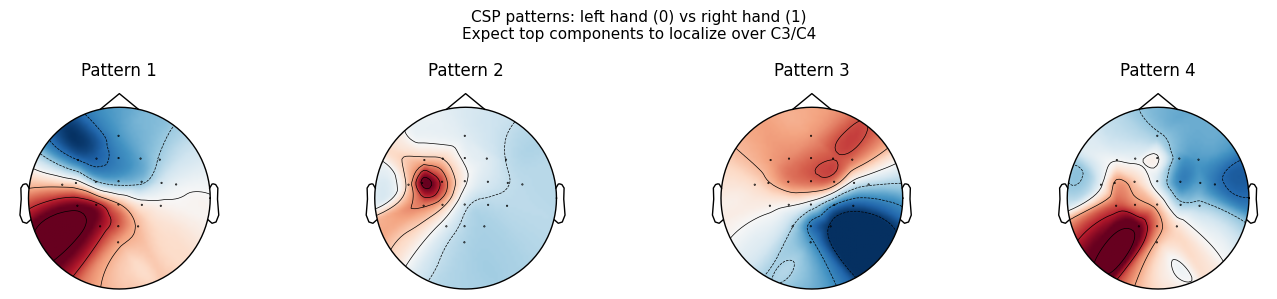

In [11]:
# Plot CSP patterns for the left-vs-right binary problem (most interpretable)
import mne

# Fit binary CSP for classes 0 (left) vs 1 (right)
X_lr = X_train[np.isin(y_train, [0, 1])]
y_lr = y_train[np.isin(y_train, [0, 1])]

binary_csp = MNE_CSP(n_components=4, reg=None, log=True, norm_trace=False,
                     transform_into='average_power')
binary_csp.fit(X_lr, y_lr)

# Dataset 2a channel names (22 EEG channels, 10-20 system)
ch_names = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz',
            'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz',
            'P2', 'POz']
info = mne.create_info(ch_names=ch_names, sfreq=250., ch_types='eeg')
info.set_montage('standard_1020')

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    mne.viz.plot_topomap(binary_csp.patterns_[i], info, axes=ax, show=False)
    ax.set_title(f'Pattern {i+1}')
fig.suptitle('CSP patterns: left hand (0) vs right hand (1)\n'
             'Expect top components to localize over C3/C4',
             fontsize=11)
plt.tight_layout()
plt.show()

### Observation — CSP patterns

> The first CSP pattern for left-vs-right imagery localizes over channel ___.
> The last CSP pattern localizes over channel ___.
> This matches our physiological prior because left-hand imagery produces ERD (power drop) over the ___ motor cortex, so a filter that maximizes class-1 (right hand) variance relative to class 0 should pick up ___.
> If CSP patterns for a subject showed no focal motor-cortex structure (e.g. diffuse frontal pattern), that would suggest ___.

*Fill in.*


## Part 3 — LDA from the ground up

### 3.1 What LDA optimizes

Linear Discriminant Analysis finds a projection of features that maximizes **between-class scatter** relative to **within-class scatter**. The intuition: classes should end up well-separated (between-class large) and compact (within-class small).

#### Definitions

Let $X \in \mathbb{R}^{N \times d}$ be your feature matrix (CSP features, $d = 16$ here), $y \in \{0, \ldots, K-1\}^N$. Denote:
- $\mu_c$ = mean of class $c$ features, shape $(d,)$
- $\mu$ = global mean, shape $(d,)$
- $N_c$ = number of samples in class $c$

**Within-class scatter** (sum of per-class covariances, unnormalized):
$$
S_W = \sum_{c=0}^{K-1} \sum_{i : y_i = c} (x_i - \mu_c)(x_i - \mu_c)^\top
$$

**Between-class scatter**:
$$
S_B = \sum_{c=0}^{K-1} N_c (\mu_c - \mu)(\mu_c - \mu)^\top
$$

Both are $d \times d$.

LDA finds projection directions $w$ maximizing:
$$
J(w) = \frac{w^\top S_B w}{w^\top S_W w}
$$

Same generalized Rayleigh quotient form as CSP. Solved by $S_B w = \lambda S_W w$.

#### Decision rule

For classification, LDA assumes each class is Gaussian with shared covariance $\Sigma = S_W / (N - K)$. The posterior is proportional to:
$$
\log p(y = c \mid x) \propto x^\top \Sigma^{-1} \mu_c - \tfrac{1}{2} \mu_c^\top \Sigma^{-1} \mu_c + \log \pi_c
$$
where $\pi_c = N_c / N$ is the class prior.

Predict: $\hat y = \arg\max_c \left[ x^\top \Sigma^{-1} \mu_c - \tfrac{1}{2} \mu_c^\top \Sigma^{-1} \mu_c + \log \pi_c \right]$.

This is a **linear** classifier (decision boundary between any two classes is a hyperplane), hence the name.

#### Why LDA often wins on CSP features

CSP features are log-variances of band-passed signals. By the central limit theorem applied to sums of squared values, log-variance of a stationary Gaussian process is approximately Gaussian. This matches LDA's assumption exactly. This is not coincidence — the CSP+LDA pipeline was designed as a pair (Ramoser et al., 2000).

> **Why X?** You can replace LDA with logistic regression or SVM, but on CSP features LDA has a closed-form solution (no iterative optimization) and strong theoretical justification. It's the right default.

### 3.2 sklearn.discriminant_analysis.LinearDiscriminantAnalysis signature

```python
LinearDiscriminantAnalysis(solver='svd', shrinkage=None, priors=None, ...)
```
- `solver`: `'svd'` (default, no shrinkage) | `'lsqr'` | `'eigen'`. Use `'lsqr'` or `'eigen'` to enable shrinkage.
- `shrinkage`: `None` | `'auto'` (Ledoit-Wolf) | float in [0, 1]. Regularizes the within-class scatter estimate when $N$ is small relative to $d$. **For EEG with ~200 training trials and 16 features, shrinkage matters.**

Methods: `.fit(X, y)` → self; `.predict(X)` → labels; `.predict_proba(X)` → probabilities shape `(N, K)`.

### 3.3 From-scratch LDA task

Implement multi-class LDA with the decision rule above. No shrinkage needed for the scratch version — you'll compare to sklearn's shrinkage version afterward.


### Task 3.1 — Implement LDA from scratch

Implement a class with `fit` and `predict`. Use the decision rule above. The covariance to invert is the pooled within-class covariance $\Sigma = S_W / (N - K)$.

**Numerical note:** `np.linalg.inv` works here because $d = 16$ is small. For larger $d$ or near-singular covariances, prefer `np.linalg.solve` or use shrinkage.

In [12]:
class LDAFromScratch:
    """
    Multi-class LDA using the Gaussian-with-shared-covariance decision rule.

    Fit computes per-class means, pooled within-class covariance, and class priors.
    Predict returns argmax over linear discriminant functions.
    """
    def fit(self, X, y):
        """
        Args:
            X: np.ndarray, shape (N, d). Feature matrix.
            y: np.ndarray, shape (N,). Integer labels in {0, ..., K-1}.
        Returns:
            self
        """
        # YOUR CODE HERE
        # Store: self.classes_, self.means_ (K, d), self.priors_ (K,),
        #        self.cov_inv_ (d, d) — inverse of pooled within-class covariance
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        N, d = X.shape

        self.means_ = np.array([X[y == c].mean(axis=0) for c in self.classes_])
        self.priors_ = np.array([np.log((y == c).mean()) for c in self.classes_])

        S_W = np.zeros((d, d))
        for c, mu_c in zip(self.classes_, self.means_):
            X_c = X[y == c] - mu_c
            S_W += X_c.T @ X_c

        Sigma = S_W / (N - K)
        self.cov_inv_ = np.linalg.inv(Sigma)
        return self

    def predict(self, X):
        """
        Args:
            X: np.ndarray, shape (N, d)
        Returns:
            y_pred: np.ndarray, shape (N,). Predicted labels.
        """
        # YOUR CODE HERE
        # For each sample, compute the discriminant score for each class:
        #   score_c(x) = x^T @ cov_inv @ mu_c - 0.5 * mu_c^T @ cov_inv @ mu_c + log(prior_c)
        # Return argmax over c.
        term1 = X @ self.cov_inv_ @ self.means_.T
        term2 = -0.5 * np.sum(self.means_ @ self.cov_inv_ * self.means_, axis=1)
        scores = term1 + term2 + self.priors_
        return self.classes_[np.argmax(scores, axis=1)]

In [13]:
# Sanity check — scratch LDA matches sklearn LDA (no shrinkage, same solver semantics)
W_full = fit_csp_ovr(X_train, y_train, n_components=4, n_classes=4)
feat_train = csp_features(X_train, W_full)
feat_test = csp_features(X_test, W_full)

_lda_ours = LDAFromScratch().fit(feat_train, y_train)
_pred_ours = _lda_ours.predict(feat_test)

_lda_sk = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=None)
_lda_sk.fit(feat_train, y_train)
_pred_sk = _lda_sk.predict(feat_test)

_agreement = (_pred_ours == _pred_sk).mean()
# They should agree on >90% of predictions (minor differences from numerical handling)
assert _agreement > 0.90, f"Scratch LDA disagrees too much with sklearn: {_agreement:.3f}"
_acc_ours = accuracy_score(y_test, _pred_ours)
print(f"Scratch LDA test accuracy: {_acc_ours:.3f}")
print(f"sklearn LDA test accuracy: {accuracy_score(y_test, _pred_sk):.3f}")
print(f"Agreement: {_agreement:.3f}")
print("✓ Scratch LDA matches sklearn closely")

Scratch LDA test accuracy: 0.644
sklearn LDA test accuracy: 0.644
Agreement: 1.000
✓ Scratch LDA matches sklearn closely


## Part 4 — Evaluation metrics: accuracy AND Cohen's kappa

### 4.1 Why accuracy is insufficient

For a 4-class problem with roughly balanced classes (Dataset 2a ≈ 72 trials per class), chance accuracy is 25%. But:
- If artifact rejection leaves classes slightly imbalanced (e.g., 70/72/68/74), a classifier that always predicts the majority class already beats chance.
- Small accuracy differences can reflect class imbalance rather than genuine decoding skill.

**Cohen's kappa** corrects for chance agreement:

$$
\kappa = \frac{p_o - p_e}{1 - p_e}
$$

- $p_o$ = observed agreement (= accuracy).
- $p_e$ = expected agreement by chance given the marginals:  
  $p_e = \sum_c \frac{n_{c, \cdot}}{N} \cdot \frac{n_{\cdot, c}}{N}$ where $n_{c,\cdot}$ is true-class-$c$ count and $n_{\cdot,c}$ is predicted-class-$c$ count.
- $\kappa = 1$ → perfect; $\kappa = 0$ → chance; $\kappa < 0$ → worse than chance.

**Dataset 2a convention:** the BCI Competition scores are reported in kappa. A kappa of 0.5 on 4-class MI is considered strong; 0.7+ is exceptional.

> **Why X?** If you report "my model hit 40% on 4-class MI" without kappa, reviewers won't know if you beat chance meaningfully. Kappa makes the comparison fair across subjects whose class balance differs after artifact rejection.

### 4.2 sklearn.metrics.cohen_kappa_score signature

```python
cohen_kappa_score(y1, y2, labels=None, weights=None, sample_weight=None)
```
- `y1`, `y2`: shape `(N,)`. For classification, treat one as true and one as predicted (symmetric).
- Returns: `float` in $[-1, 1]$.


### Task 4.1 — Evaluation helper

Write a small helper that returns both accuracy and kappa. You'll call this in every subject evaluation.

In [14]:
def evaluate(y_true, y_pred):
    """
    Compute accuracy and Cohen's kappa.

    Args:
        y_true: np.ndarray, shape (N,). Ground-truth labels.
        y_pred: np.ndarray, shape (N,). Predicted labels.

    Returns:
        dict with keys 'accuracy' and 'kappa', both floats.
    """
    # YOUR CODE HERE
    acc = np.sum(y_true==y_pred)/len(y_pred)
    kappa = cohen_kappa_score(y_true,y_pred,labels=None,weights=None,sample_weight=None)
    return {'accuracy':acc,'kappa':kappa}

In [15]:
# Sanity check — perfect predictions give kappa = 1, random predictions give kappa near 0
_y = np.array([0, 1, 2, 3, 0, 1, 2, 3])
_perfect = evaluate(_y, _y)
assert _perfect['accuracy'] == 1.0 and _perfect['kappa'] == 1.0

# Random predictions on many samples should give kappa near 0
_rng = np.random.RandomState(0)
_y_true = _rng.randint(0, 4, size=10000)
_y_rand = _rng.randint(0, 4, size=10000)
_rand = evaluate(_y_true, _y_rand)
assert abs(_rand['kappa']) < 0.03, f"Random kappa should be ~0, got {_rand['kappa']:.3f}"
assert 0.22 < _rand['accuracy'] < 0.28, f"Random accuracy should be ~0.25, got {_rand['accuracy']:.3f}"
print(f"✓ evaluate() works: perfect → acc 1.0, kappa 1.0; random → acc {_rand['accuracy']:.3f}, kappa {_rand['kappa']:.3f}")

✓ evaluate() works: perfect → acc 1.0, kappa 1.0; random → acc 0.255, kappa 0.006


## Part 5 — Put it together: CSP + LDA on subject A01

Now assemble the full pipeline and evaluate on subject A01's test set.


### Hypothesis cell

Before running: the BCI Competition IV Dataset 2a leaderboard puts strong subject-specific pipelines around **kappa ≈ 0.55–0.65 mean across subjects**, with good subjects (A01, A03, A07, A08, A09) reaching kappa > 0.7 and poor subjects (A02, A04, A05, A06) at 0.3–0.4.

> My prediction: CSP (n_components=4 per class, 16 total) + LDA (shrinkage='auto') on subject A01 will achieve:
> - Accuracy: ___%  
> - Kappa: ___  
>
> I predict this based on: ___.

*Fill in, then run.*


In [19]:
# Full pipeline on subject A01
data = run_pipeline('A01', DATA_DIR)

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

# 1. Fit CSP on training data ONLY
W = fit_csp_ovr(X_train, y_train, n_components=4, n_classes=4)

# 2. Extract features
feat_train = csp_features(X_train, W)
feat_test = csp_features(X_test, W)

# 3. Fit LDA with shrinkage (standard for small-N EEG)
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda.fit(feat_train, y_train)

# 4. Evaluate
y_pred = lda.predict(feat_test)
result = evaluate(y_test, y_pred)
acc_lda   = result['accuracy']
kappa_lda = result['kappa']
print(f"Subject A01 — CSP + LDA (shrinkage=auto)")
print(f"  Accuracy: {result['accuracy']:.3f}")
print(f"  Kappa:    {result['kappa']:.3f}")

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
Subject A01 — CSP + LDA (shrinkage=auto)
  Accuracy: 0.644
  Kappa:    0.525


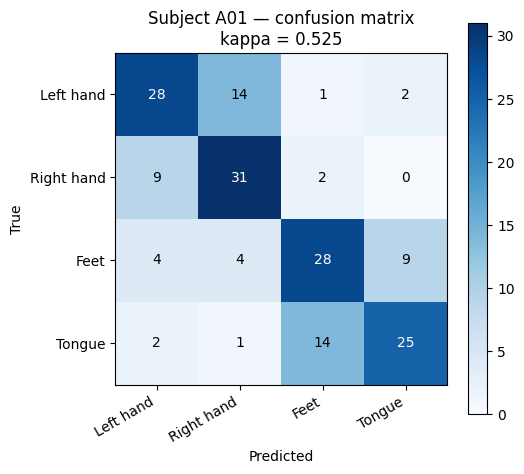

In [20]:
# Confusion matrix — which classes get confused with which?
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
class_names = ['Left hand', 'Right hand', 'Feet', 'Tongue']

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Subject A01 — confusion matrix\nkappa = {result["kappa"]:.3f}')
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Observation — A01 confusion matrix

> On A01, the most-confused class pair is ___ predicted as ___. The physiological reason this pair is hard is ___ (hint: which motor cortex regions are involved in each? how are they spatially separated on the scalp?).
> The best-classified class is ___, which makes sense because ___.

*Fill in.*


## Part 6 — SVM: max-margin as an alternative to LDA

### 6.1 Why SVM at all?

LDA's optimality depends on Gaussian class-conditionals with shared covariance. For real EEG, these assumptions are only approximately true. When they break:
- Outlier trials (residual artifacts, attention lapses) pull class means and covariances.
- Non-Gaussian tails bias the discriminant.

**SVM** makes no distributional assumption. It finds the hyperplane that maximizes the margin between classes — only the **support vectors** (points near the boundary) affect the decision. This makes it more robust to outliers within each class.

#### The formulation

Binary SVM finds $w, b$ solving:
$$
\min_{w, b, \xi} \tfrac{1}{2}\|w\|^2 + C \sum_i \xi_i
\quad \text{s.t.} \quad y_i(w^\top x_i + b) \geq 1 - \xi_i,\ \xi_i \geq 0
$$

- $\|w\|^2$: inverse-margin (small $w$ = wide margin).
- $\xi_i$: slack for points inside the margin or misclassified.
- $C$: trade-off between margin width and training errors. Small $C$ → wide margin, more errors tolerated. Large $C$ → fit training data hard.

For 4-class, sklearn uses **one-vs-one** by default: $\binom{4}{2} = 6$ binary SVMs, vote for the final class.

#### Kernel choice

- **Linear kernel** ($K(x, x') = x^\top x'$): decision boundary is a hyperplane in feature space. Fast, few hyperparameters (just $C$).
- **RBF kernel** ($K(x, x') = \exp(-\gamma \|x - x'\|^2)$): non-linear boundary. Two hyperparameters ($C$, $\gamma$).

**For CSP features, linear usually wins.** CSP features are already discriminatively engineered; non-linearity rarely helps and risks overfitting on ~200 samples.

> **Why X?** In published Dataset 2a benchmarks, CSP+LDA and CSP+linear-SVM are usually within 1–2 kappa points of each other. The point of running both is not to decide a "winner" on one subject — it's to understand which is more stable across subjects. You'll see this in Part 7.

### 6.2 sklearn.svm.SVC signature

```python
SVC(C=1.0, kernel='rbf', gamma='scale', decision_function_shape='ovr', ...)
```
- `C`: float. Regularization. Default 1.0.
- `kernel`: `'linear'` | `'poly'` | `'rbf'` | `'sigmoid'`.
- `gamma`: for RBF/poly. `'scale'` = $1 / (d \cdot \text{Var}(X))$; `'auto'` = $1 / d$; or a float.
- `decision_function_shape='ovr'`: the *public* decision function is one-vs-rest even though internally it fits one-vs-one.
- `.fit(X, y)`, `.predict(X)` — same as LDA.


### Task 6.1 — Fit SVM on CSP features

Fit two SVMs on the A01 CSP features you already computed: one with `kernel='linear'`, one with `kernel='rbf'`. Both with default `C=1.0`. Compare to LDA on the same features.

No wrapper function needed — just fit, predict, evaluate.

In [21]:
# YOUR CODE HERE
# 1. Fit SVC(kernel='linear') on feat_train, y_train; predict on feat_test; evaluate.
# 2. Same with kernel='rbf'.
# 3. Print a comparison table: LDA (already computed above), Linear SVM, RBF SVM,
#    with accuracy and kappa for each.
svc_linear = SVC(kernel='linear')
svc_linear.fit(feat_train, y_train)
pred_linear = svc_linear.predict(feat_test)
acc_linear   = accuracy_score(y_test, pred_linear)
kappa_linear = cohen_kappa_score(y_test, pred_linear)

svc_rbf = SVC(kernel='rbf')
svc_rbf.fit(feat_train, y_train)
pred_rbf = svc_rbf.predict(feat_test)
acc_rbf   = accuracy_score(y_test, pred_rbf)
kappa_rbf = cohen_kappa_score(y_test, pred_rbf)

print(f"{'Model':<20} {'Accuracy':>10} {'Kappa':>10}")
print("-" * 42)
print(f"{'LDA':<20} {acc_lda:>10.3f} {kappa_lda:>10.3f}")
print(f"{'SVM (linear)':<20} {acc_linear:>10.3f} {kappa_linear:>10.3f}")
print(f"{'SVM (rbf)':<20} {acc_rbf:>10.3f} {kappa_rbf:>10.3f}")

Model                  Accuracy      Kappa
------------------------------------------
LDA                       0.644      0.525
SVM (linear)              0.626      0.502
SVM (rbf)                 0.454      0.280


### Decision — LDA vs SVM

1. On CSP features for A01, which classifier did best? Was the gap meaningful (e.g., > 0.05 kappa) or noise-level?
2. Linear SVM and LDA both produce a linear decision boundary in feature space. Their predictions differ. Why? (Think: what does each *optimize*?)
3. For a deployed BCI that calibrates on 200 trials per user, which would you ship, and why? Consider: sensitivity to outliers, interpretability (inspecting $w$), training time, hyperparameter tuning burden.

*Write your answers here.*


## Part 7 — Full 9-subject sweep

Single-subject numbers are not publishable. The literature reports **mean ± std over all 9 Dataset 2a subjects**. Produce this table for CSP+LDA, CSP+linear SVM, and CSP+RBF SVM.

### The subject loop contract

For each subject A01–A09:
1. Call `run_pipeline(subj, DATA_DIR)` → `X_train, X_test, y_train, y_test`.
2. Fit CSP on training data only (never touch test for fitting).
3. Transform train and test.
4. Fit each classifier on train, predict on test, evaluate.
5. Store results per subject per method.

At the end: print the table with mean ± std across subjects for each method.

### Hypothesis cell

> I predict the mean kappa across 9 subjects will be:
> - CSP + LDA: ___  
> - CSP + linear SVM: ___  
> - CSP + RBF SVM: ___  
>
> I expect the **standard deviation** across subjects to be (small / large) because ___.
> I expect subject A02 to be (better / worse) than average because ___ (hint: check the Dataset 2a paper; some subjects are known to have poor BCI illiteracy).

*Fill in, then run.*


In [22]:
def run_csp_classifier(X_train, X_test, y_train, y_test, classifier, n_components=4, n_classes=4):
    """
    End-to-end CSP + classifier pipeline.

    Args:
        X_train, X_test: np.ndarray, shape (n_trials, C, T)
        y_train, y_test: np.ndarray, shape (n_trials,)
        classifier: sklearn-style estimator with .fit() and .predict()
        n_components: CSP components per class (one-vs-rest)

    Returns:
        dict with 'accuracy' and 'kappa' on the test set.
    """
    # YOUR CODE HERE
    W = fit_csp_ovr(X_train, y_train, n_components=n_components, n_classes=n_classes)
    feat_train = csp_features(X_train, W)
    feat_test  = csp_features(X_test,  W)
    
    classifier.fit(feat_train, y_train)
    y_pred = classifier.predict(feat_test)
    
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'kappa':    cohen_kappa_score(y_test, y_pred)
    }

In [24]:
# 9-subject sweep
from sklearn.base import clone

methods = {
    'CSP+LDA':        LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'CSP+linearSVM':  SVC(kernel='linear', C=1.0),
    'CSP+rbfSVM':     SVC(kernel='rbf',    C=1.0, gamma='scale'),
}

subjects = [f'A0{i}' for i in range(1, 10)]
results = {m: {} for m in methods}

for subj in subjects:
    data = run_pipeline(subj, DATA_DIR)

    Xtr = data['X_train']
    Xte  = data['X_test']
    ytr = data['y_train']
    yte  = data['y_test']
    for name, clf in methods.items():
        res = run_csp_classifier(Xtr, Xte, ytr, yte, clone(clf))
        results[name][subj] = res
    print(f"{subj}: " + "  ".join(
        f"{name} κ={results[name][subj]['kappa']:.3f}" for name in methods))

  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
A01: CSP+LDA κ=0.525  CSP+linearSVM κ=0.502  CSP+rbfSVM κ=0.280
  A02T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
A02: CSP+LDA κ=0.201  CSP+linearSVM κ=0.185  CSP+rbfSVM κ=0.114
  A03T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
A03: CSP+LDA κ=0.655  CSP+linearSVM κ=0.663  CSP+rbfSVM κ=0.265
  A04T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
A04: CSP+LDA κ=0.257  CSP+linearSVM κ=0.288  CSP+rbfSVM κ=0.144
  A05T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
A05: CSP+LDA κ=0.094  CSP+linearSVM κ=0.147  CSP+rbfSVM κ=0.061
  A06T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
A06: CSP+LDA κ=0.280  CSP+linearSVM κ=0.218  CSP+rbfSVM κ=0.000
  A07T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
A07: CSP+LDA κ=0.516  CSP+linearSVM κ=0.501  CSP+rbfSVM κ=0.280
  A08T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
A08: CSP

In [25]:
# Summary table
print(f"{'Method':<18} {'Acc mean ± std':<22} {'Kappa mean ± std':<22}")
print("-" * 62)
for name in methods:
    accs = [results[name][s]['accuracy'] for s in subjects]
    kapps = [results[name][s]['kappa'] for s in subjects]
    print(f"{name:<18} {np.mean(accs):.3f} ± {np.std(accs):.3f}       "
          f"{np.mean(kapps):.3f} ± {np.std(kapps):.3f}")

Method             Acc mean ± std         Kappa mean ± std      
--------------------------------------------------------------
CSP+LDA            0.559 ± 0.144       0.411 ± 0.192
CSP+linearSVM      0.556 ± 0.139       0.408 ± 0.186
CSP+rbfSVM         0.381 ± 0.118       0.183 ± 0.155


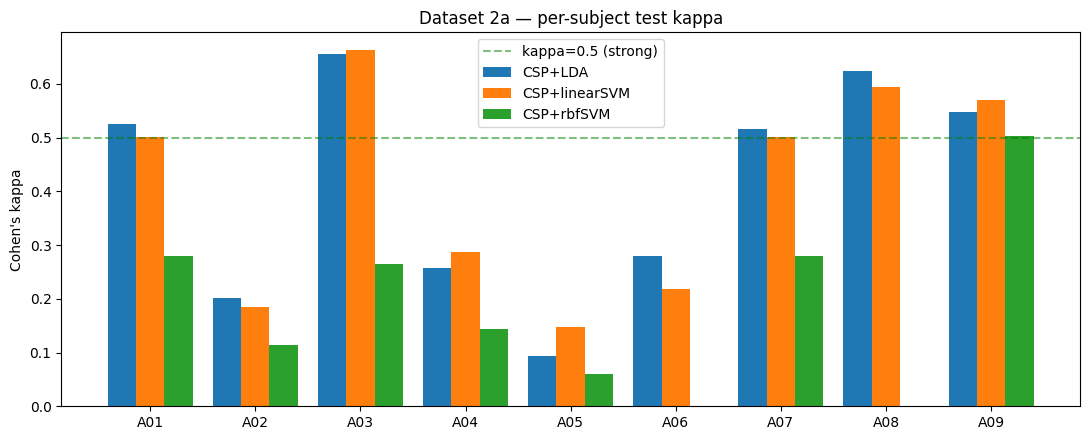

In [26]:
# Per-subject kappa bar chart
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(subjects))
width = 0.27
for i, name in enumerate(methods):
    kapps = [results[name][s]['kappa'] for s in subjects]
    ax.bar(x + (i - 1) * width, kapps, width, label=name)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axhline(0.5, color='green', linestyle='--', alpha=0.5, label='kappa=0.5 (strong)')
ax.set_xticks(x); ax.set_xticklabels(subjects)
ax.set_ylabel("Cohen's kappa"); ax.set_title('Dataset 2a — per-subject test kappa')
ax.legend()
plt.tight_layout()
plt.show()

### Observation — full sweep

> Across 9 subjects:
> - CSP+LDA achieved kappa ___ ± ___  
> - CSP+linearSVM achieved kappa ___ ± ___  
> - CSP+rbfSVM achieved kappa ___ ± ___  
>
> The **best** subject was A0___ (kappa ___), the **worst** was A0___ (kappa ___). The spread of ___ kappa points across subjects is a core challenge in BCI: it shows that ___ .
>
> Comparing to published CSP+LDA numbers on Dataset 2a (Ang et al. 2008 FBCSP: kappa ≈ 0.57 with filter banks; plain CSP+LDA typically 0.50–0.55): my result is (consistent / low / high) because ___.
>
> RBF SVM (did / did not) outperform linear SVM on average. If it did worse, this is consistent with the intuition that ___. If it did better, it suggests ___.

*Fill in.*


## Part 8 — Ablation: CSP component count

How does performance change with `n_components`? Theory says more components → more features → better until overfitting kicks in. For CSP+LDA on ~200 training trials, the typical sweet spot is 2–6 per binary problem (8–24 total features for 4 classes).

### Hypothesis cell

> I predict that kappa will (increase / decrease / plateau / rise then fall) as n_components goes from 2 to 10. The mechanism is: with too few components ___; with too many components ___.

*Fill in.*


  A01T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A02T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A03T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A04T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A05T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A06T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A07T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A08T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]
  A09T: 288 epochs, shape (288, 22, 501), class dist: [72 72 72 72]


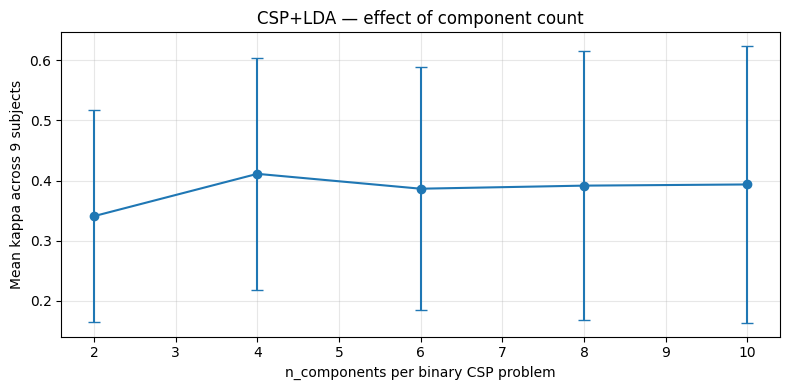

n_components= 2:  kappa = 0.341 ± 0.176  (total features = 8)
n_components= 4:  kappa = 0.411 ± 0.192  (total features = 16)
n_components= 6:  kappa = 0.386 ± 0.202  (total features = 24)
n_components= 8:  kappa = 0.392 ± 0.223  (total features = 32)
n_components=10:  kappa = 0.394 ± 0.230  (total features = 40)


In [28]:
# Sweep n_components on all 9 subjects with CSP+LDA
component_sweep = [2, 4, 6, 8, 10]
sweep_results = {nc: [] for nc in component_sweep}

for subj in subjects:
    data = run_pipeline(subj, DATA_DIR)

    Xtr = data['X_train']
    Xte  = data['X_test']
    ytr = data['y_train']
    yte  = data['y_test']
    for nc in component_sweep:
        lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
        res = run_csp_classifier(Xtr, Xte, ytr, yte, lda, n_components=nc)
        sweep_results[nc].append(res['kappa'])

# Plot mean ± std
means = [np.mean(sweep_results[nc]) for nc in component_sweep]
stds = [np.std(sweep_results[nc]) for nc in component_sweep]

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(component_sweep, means, yerr=stds, marker='o', capsize=4)
ax.set_xlabel('n_components per binary CSP problem')
ax.set_ylabel("Mean kappa across 9 subjects")
ax.set_title('CSP+LDA — effect of component count')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for nc, m, s in zip(component_sweep, means, stds):
    print(f"n_components={nc:2d}:  kappa = {m:.3f} ± {s:.3f}  (total features = {nc * 4})")

### Observation — component sweep

> The best n_components across 9 subjects was ___, giving mean kappa ___.
> The curve (shape: monotonic / peaked / flat) is consistent with (my / not my) hypothesis.
> Going from n_components=2 to 4 changed kappa by ___; from 4 to 10 by ___. This tells me that ___.
>
> For a shipped BCI, I would pick n_components = ___ because ___ (consider: kappa, feature count, interpretability of topographies, risk of subject-specific overfitting when you re-calibrate on a new user's 50 trials).

*Fill in.*


## Part 9 — Wrap-up

### What you should be able to do now

1. Derive CSP from the generalized Rayleigh quotient and implement it in NumPy.
2. Explain why log-variance features + LDA form a theoretically principled pair for motor imagery.
3. Compute and interpret Cohen's kappa, and explain why accuracy alone is insufficient for multi-class BCI reporting.
4. Produce a 9-subject Dataset 2a results table and compare numerically to the published CSP+LDA baseline (~0.55 kappa).
5. Reason about when CSP+LDA is the right default vs. when SVM or deep learning would be preferred.

### Bridge to Notebook 5 — EEGNet

CSP's limitation: spatial filters are fit on band-passed data with a **fixed** frequency band (8–30 Hz). Information outside this band or at frequencies where different subjects' motor rhythms peak is lost. Filter Bank CSP (FBCSP) addresses this by running CSP at multiple bands and selecting features — but it's still hand-crafted.

**EEGNet** does the same thing end-to-end:
- Temporal convolution = learned band-pass filtering (replaces the fixed 8–30 Hz filter).
- Depthwise spatial convolution = learned spatial filtering (replaces CSP).
- Separable temporal convolution = learned feature extraction (replaces log-variance).

The mapping from CSP+LDA to EEGNet is almost one-to-one at a conceptual level. The next notebook makes this explicit.

### Save your baseline for the capstone

The final capstone notebook (Notebook 7) will compare CSP+LDA, EEGNet, and EEG Conformer on the same 9-subject evaluation. Save your results dict now so you don't rerun the sweep later.

In [29]:
import pickle
os.makedirs('metrics', exist_ok=True)
# Store per-method, per-subject results for later comparison
baseline_results = {
    'method': 'CSP+LDA',
    'per_subject': results['CSP+LDA'],
    'n_components': 4,
    'classifier_config': {'solver': 'lsqr', 'shrinkage': 'auto'},
}
with open('metrics/csp_lda_baseline.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

# Also save all methods for direct comparison in capstone
all_baselines = {
    name: {'per_subject': results[name]} for name in methods
}
with open('metrics/csp_all_classifiers.pkl', 'wb') as f:
    pickle.dump(all_baselines, f)

print("Saved baseline results to metrics/csp_lda_baseline.pkl and metrics/csp_all_classifiers.pkl")

Saved baseline results to metrics/csp_lda_baseline.pkl and metrics/csp_all_classifiers.pkl
